In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [17]:
file_path = "E:\\ML\\Book1.csv"   # Replace with your actual CSV path
df = pd.read_csv(file_path)
df

,App Name,Category,Usage Time (min),Frequency,Label
0,Instagram,Social,360,50,Distracting
1,Facebook,Social,240,30,Distracting
2,YouTube,Entertainment,420,35,Working
3,Candy Crush,Game,180,20,Distracting
4,wps office,Entertainment,600,15,working
5,Gmail,Productivity,600,10,Working
6,Google Docs,Productivity,480,5,Working
7,VS Code,Productivity,720,8,Working
8,Coursera,Educational,540,6,Working
9,Zoom,Communication,240,7,Working


In [18]:
# Step 2: Convert columns to numeric and clean data
df['Usage Time (min)'] = pd.to_numeric(df['Usage Time (min)'], errors='coerce')
df['Frequency'] = pd.to_numeric(df['Frequency'], errors='coerce')
df = df.dropna(subset=['Usage Time (min)', 'Frequency']).reset_index(drop=True)

In [19]:
# Step 3: Create 'Label' column if not present
if 'Label' not in df.columns:
    distracting_cats = ['Social', 'Entertainment', 'Game', 'Communication']
    df['Label'] = np.where(df['Category'].isin(distracting_cats), 'Distracting', 'Working')

In [20]:
le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df['Label'])

In [6]:
X = df[['Usage Time (min)', 'Frequency']]
y = df['Label_enc']

In [21]:
X = df[['Usage Time (min)', 'Frequency']]
y = df['Label_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
df['Predicted_Label'] = rf.predict(X)


In [24]:
# Step 8: Create an alert for overused distracting apps
threshold_minutes = 15
distracting_index = le.transform(['Distracting'])[0]
df['Alert'] = np.where(
    (df['Predicted_Label'] == distracting_index) & (df['Usage Time (min)'] > threshold_minutes),
    'Alert',
    'Normal'
)

In [25]:
df_sorted = df.sort_values(by='Usage Time (min)', ascending=False)


In [26]:
colors = ['red' if a == 'Alert' else 'green' for a in df_sorted['Alert']]


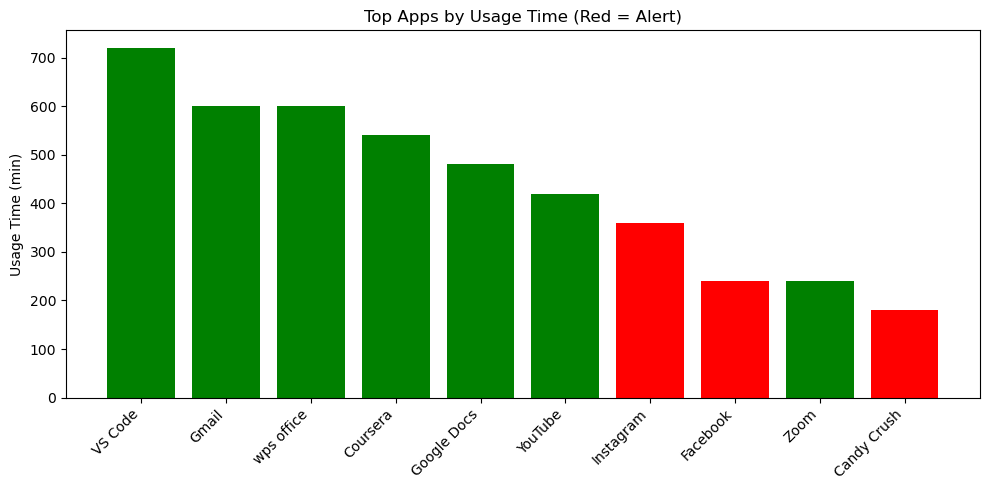

In [27]:
# Step 11: Visualize top apps by usage time
plt.figure(figsize=(10, 5))
plt.bar(df_sorted['App Name'], df_sorted['Usage Time (min)'], color=colors)
plt.title('Top Apps by Usage Time (Red = Alert)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Usage Time (min)')
plt.tight_layout()
plt.show()

In [2]:
# Import necessary libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Step 1: Load Data
file_path = "Book1.csv"   # Replace with your actual CSV path
df = pd.read_csv(file_path)

# Step 2: Convert columns to numeric and clean data
df['Usage Time (min)'] = pd.to_numeric(df['Usage Time (min)'], errors='coerce')
df['Frequency'] = pd.to_numeric(df['Frequency'], errors='coerce')
df = df.dropna(subset=['Usage Time (min)', 'Frequency']).reset_index(drop=True)

# Step 3: Create 'Label' column if not present
if 'Label' not in df.columns:
    distracting_cats = ['Social', 'Entertainment', 'Game', 'Communication']
    df['Label'] = np.where(df['Category'].isin(distracting_cats), 'Distracting', 'Working')

# Step 4: Label Encoding
le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df['Label'])

# Step 5: Feature and Target Selection
X = df[['Usage Time (min)', 'Frequency']]
y = df['Label_enc']

# Step 6: Split Data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 7: Train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 8: Predict Labels on Test Set
y_pred = rf.predict(X_test)

# Step 9: Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Random Forest Evaluation Metrics (Test Set)\n")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}\n")

print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Step 10: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Step 11: Predict for entire dataset (Optional: alerts visualization)
df['Predicted_Label'] = rf.predict(X)

threshold_minutes = 15
distracting_index = le.transform(['Distracting'])[0]
df['Alert'] = np.where(
    (df['Predicted_Label'] == distracting_index) & (df['Usage Time (min)'] > threshold_minutes),
    'Alert',
    'Normal'
)

df_sorted = df.sort_values(by='Usage Time (min)', ascending=False)
colors = ['red' if a == 'Alert' else 'green' for a in df_sorted['Alert']]

plt.figure(figsize=(10, 5))
plt.bar(df_sorted['App Name'], df_sorted['Usage Time (min)'], color=colors)
plt.title('Top Apps by Usage Time (Red = Alert)')
plt.xlabel('App Name')
plt.ylabel('Usage Time (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


ERROR: Could not find a version that satisfies the requirement scikit-learn (from versions: none)
ERROR: No matching distribution found for scikit-learn


ModuleNotFoundError: No module named 'pandas'